# Modelagem — escola–ano (Ensino Médio)

Este notebook atende aos **requisitos 3, 4** e à **comparação multi-modelo** do projeto:

- **Requisito 3:** carregamento dos dados a partir da saída do ETL, análise exploratória inicial, tratamento reprodutível (`sklearn.pipeline.Pipeline` + módulo `ml/baseline_municipio.py`).
- **Requisito 4:** modelo baseline (**Ridge**) com **validação temporal** e métricas no conjunto de teste (MAE, RMSE, R²), comparado a um **DummyRegressor** (média do treino).
- **Comparação adicional:** **ElasticNet** e **HistGradientBoostingRegressor** frente ao Ridge/Dummy, mesmas métricas e visualizações (§7).

**Granularidade:** `fato_integrado` tem **uma linha por escola e ano** (registros da base educacional). Os indicadores socioeconômicos do município são **os mesmos para todas as escolas do ano**.

**Alvo do baseline:** `taxa_abandono_em` — formalmente: *estimar a taxa de abandono escolar no Ensino Médio como indicador associado ao risco de evasão escolar* (`docs/definicao_problema_e_escopo.md`). **`taxa_evasao_em`** entra como **covariável municipal** (contexto compartilhado). **Exclusão de vazamento:** não usar `indice_risco_evasao` como preditor.

## 1. Ambiente e reprodutibilidade

Execute a partir da **raiz do repositório** (para que `data/` e `ml/` resolvam corretamente). Versões recomendadas: `requirements.txt`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "ml").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from ml import baseline_municipio as bl

## 2. Carregamento dos dados

Se `data/processed/fato_integrado.csv` não existir, o módulo **dispara o ETL automaticamente** (mesma lógica do dashboard).

In [2]:
df = bl.load_fato_integrado()
df = df.sort_values("ano").reset_index(drop=True)
print("Dimensão:", df.shape)
print("Anos:", df["ano"].min(), "—", df["ano"].max())
df.head()

Dimensão: (15, 21)
Anos: 2008 — 2022


,ano,taxa_promocao_ef,taxa_promocao_em,taxa_repetencia_ef,taxa_repetencia_em,taxa_evasao_ef,taxa_evasao_em,periodo,atu_ef,atu_em,...,had_em,tdi_ef,tdi_em,taxa_aprovacao_ef,taxa_aprovacao_em,taxa_reprovacao_ef,taxa_reprovacao_em,taxa_abandono_ef,taxa_abandono_em,indice_risco_evasao
0,2008,70.97,64.60,9.28,7.90,12.65,27.07,2006–2010,27.00,37.69,...,NaN,24.02,47.63,77.87,72.09,14.76,11.97,7.38,15.94,27.49
1,2009,69.70,66.40,17.00,13.32,11.28,19.35,2006–2010,24.71,36.58,...,NaN,24.16,48.84,81.91,76.60,13.76,11.84,4.33,11.56,26.39
2,2010,66.75,71.57,20.85,12.57,11.15,15.33,2006–2010,25.25,36.17,...,4.68,26.64,50.68,84.72,74.70,10.85,14.07,4.42,11.23,25.11
3,2011,73.50,75.17,8.88,9.37,15.98,14.13,2011–2015,24.44,36.35,...,5.18,25.12,40.60,85.70,72.93,10.58,17.12,3.72,9.95,20.64
4,2012,73.47,75.63,12.72,10.73,12.42,12.17,2011–2015,25.90,35.82,...,5.38,21.93,34.88,86.88,77.58,10.45,15.70,2.67,6.72,18.55


## 3. Análise exploratória inicial

Completude, distribuição do alvo e lista de colunas numéricas vs. categóricas usadas na modelagem.

In [3]:
target = bl.TARGET
print("Taxa de valores ausentes (top 15):\n")
print(df.isna().sum().sort_values(ascending=False).head(15))

print("\n--- Estatísticas do alvo (% evasão EM) ---")
print(df[target].describe().round(3))

Taxa de valores ausentes (top 15):

had_em                2
had_ef                2
taxa_abandono_ef      1
taxa_abandono_em      1
taxa_reprovacao_em    1
taxa_aprovacao_em     1
taxa_reprovacao_ef    1
taxa_aprovacao_ef     1
taxa_repetencia_em    0
ano                   0
taxa_repetencia_ef    0
taxa_promocao_em      0
taxa_promocao_ef      0
tdi_ef                0
atu_em                0
dtype: int64

--- Estatísticas do alvo (% evasão EM) ---
count    15.000
mean     10.691
std       6.296
min       4.070
25%       5.585
50%       9.500
75%      13.150
max      27.070
Name: taxa_evasao_em, dtype: float64


In [4]:
num_cols, cat_cols = bl.infer_feature_columns(df)
print("Features numéricas:", len(num_cols))
print(num_cols)
print("\nFeatures categóricas:", cat_cols)

Features numéricas: 18
['ano', 'taxa_promocao_ef', 'taxa_promocao_em', 'taxa_repetencia_ef', 'taxa_repetencia_em', 'taxa_evasao_ef', 'atu_ef', 'atu_em', 'had_ef', 'had_em', 'tdi_ef', 'tdi_em', 'taxa_aprovacao_ef', 'taxa_aprovacao_em', 'taxa_reprovacao_ef', 'taxa_reprovacao_em', 'taxa_abandono_ef', 'taxa_abandono_em']

Features categóricas: ['periodo']


## 4. Tratamento e transformação (pipeline modular)

- **Numéricas:** `SimpleImputer(median)` + `StandardScaler`  
- **Categóricas** (`periodo`): `SimpleImputer(most_frequent)` + `OneHotEncoder`  
- **Modelo:** `Ridge` (regularização L2 adequada a **n pequeno** e multicolinearidade)

A implementação está centralizada em `ml/baseline_municipio.py` para facilitar testes e integração futura.

## 5. Baseline + validação temporal (requisito 4)

- **Treino:** anos `<= 2017`  
- **Teste:** anos `>= 2018`  

Justificativa: séries temporais municipais não devem ser embaralhadas aleatoriamente; o horizonte recente simula uso operacional (treino no passado, teste em anos mais novos).

Com **n ≈ 15** anos totais, este split é ilustrativo e deve ser complementado (ex.: validação cruzada temporal) em etapas posteriores.

In [5]:
resultado = bl.run_baseline_experiment(year_cutoff=2017, ridge_alpha=1.0)

print("Anos de treino:", resultado["train_years"])
print("Anos de teste :", resultado["test_years"])
print("n_train =", resultado["n_train"], "| n_test =", resultado["n_test"])
print()
print("--- DummyRegressor (sempre a média do treino) ---")
print(resultado["metrics_dummy_mean"])
print()
print("--- Ridge (alpha=1.0) ---")
print(resultado["metrics_ridge"])

Anos de treino: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017]
Anos de teste : [2018, 2019, 2020, 2021, 2022]
n_train = 10 | n_test = 5

--- DummyRegressor (sempre a média do treino) ---
{'mae': 8.184999999999997, 'rmse': 8.205876491880678, 'r2': -195.78421258737987}

--- Ridge (alpha=1.0) ---
{'mae': 1.6018426677570983, 'rmse': 2.763981566513586, 'r2': -21.3259828046516}


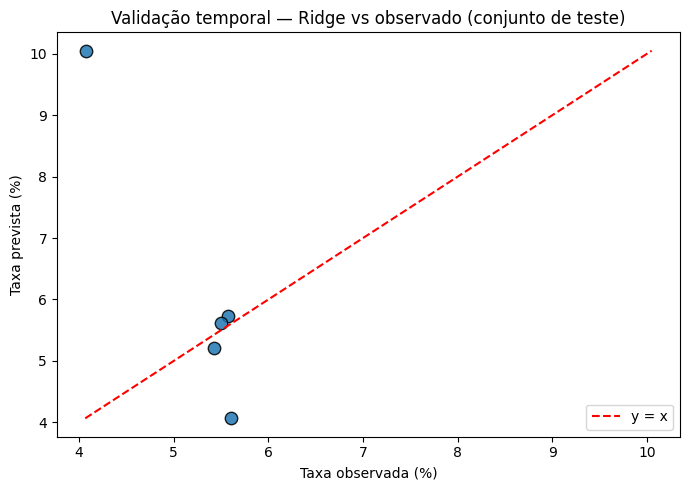

In [6]:
y_test = resultado["y_test"]
y_hat = resultado["y_pred_ridge"]
anos_teste = resultado["test_years"]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_hat, s=80, alpha=0.85, edgecolors="k")
lim = min(y_test.min(), y_hat.min()), max(y_test.max(), y_hat.max())
ax.plot(lim, lim, "r--", lw=1.5, label="y = x")
ax.set_xlabel("Abandono EM observado (%)")
ax.set_ylabel("Abandono EM previsto (%)")
ax.set_title("Validação temporal — Ridge vs observado (abandono EM, conjunto de teste)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Leitura dos resultados

- **MAE** em pontos percentuais indica erro médio absoluto na **taxa de abandono EM** (alvo do baseline).
- Com poucos anos de teste, **R² pode ser instável**; use como referência, não como único critério.
- Se o Ridge não superar claramente o dummy, isso **não invalida** o pipeline — indica que o sinal preditivo é fraco no recorte atual ou que o teste é minúsculo.

A **comparação com outros algoritmos de regressão** (ElasticNet, boosting em gradiente) e os gráficos associados estão na **§7**. Próximos passos possíveis: tuning de hiperparâmetros, `TimeSeriesSplit` / LOYO, integração ao dashboard.

## 7. Comparação multi-modelo (métricas + visualizações)

Quatro estimadores no **mesmo split temporal** que o §5: **Dummy** (média), **Ridge**, **ElasticNet** (L1+L2) e **HistGradientBoostingRegressor**. Métricas no teste: **MAE**, **RMSE**, **R²**.

As figuras incluem barras de métricas, **R²**, painel **observado × previsto** e **boxplot dos erros** (previsto − observado). Com `save_dir`, os PNG são gravados em `outputs/figures/` para relatórios.

In [ ]:
from IPython.display import display

FIG_DIR = ROOT / "outputs" / "figures"
cmp = bl.run_model_comparison_experiment(year_cutoff=2017, ridge_alpha=1.0)

print("Anos de treino:", cmp["train_years"], "| teste:", cmp["test_years"])
print("n_train =", cmp["n_train"], "| n_test =", cmp["n_test"])
print()
display(bl.metrics_comparison_dataframe(cmp["metrics_by_model"]))

paths = bl.plot_model_comparison_figures(
    cmp["y_test"],
    cmp["metrics_by_model"],
    cmp["predictions_by_model"],
    save_dir=FIG_DIR,
    show=True,
)
print("Figuras gravadas em:", FIG_DIR)
for p in paths:
    print(" -", p)